# Model Training, Testing and Evaluation

In [1]:
import pandas as pd
import numpy as np
import os
import joblib
import json
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, classification_report, RocCurveDisplay, ConfusionMatrixDisplay
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from matplotlib.patches import Patch

In [2]:
df = pd.read_parquet("../data/processed/final/address_level_fused.parquet")

with open('../../models/address_features_metadata.json', 'r') as f:
    meta = json.load(f)

onchain_features  = meta['onchain_features']
market_features   = meta['market_features']
reddit_features   = meta['reddit_features']
twitter_features  = meta['twitter_features']

ALL_FEATURES = onchain_features + market_features + reddit_features + twitter_features
TARGET = 'is_scam'

### Train/test split

In [3]:
X = df[ALL_FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

print(f"\nFeatures: {len(ALL_FEATURES)} features (On-chain:{len(onchain_features)} Market:{len(market_features)} Reddit:{len(reddit_features)} Twitter:{len(twitter_features)})")

print(f"Train size: {len(X_train)}  Test size: {len(X_test)}")
print(f"Train scam ratio: {y_train.mean():.2%}")
print(f"Test scam ratio:  {y_test.mean():.2%}")


Features: 31 features (On-chain:14 Market:5 Reddit:3 Twitter:9)
Train size: 28217  Test size: 7055
Train scam ratio: 16.28%
Test scam ratio:  16.27%


### Train XGBoost Model

In [4]:
BASE_PARAMS = {
    'n_estimators': 200,
    'max_depth': 5,
    'learning_rate': 0.05,
    'min_child_weight': 3,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'eval_metric': 'logloss',
    'random_state': 42,
    'n_jobs': -1,
}

In [5]:
final_model = xgb.XGBClassifier(**BASE_PARAMS)
final_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Predictions

In [6]:
y_train_pred = (final_model.predict_proba(X_train)[:, 1] >= 0.5).astype(int)
y_test_prob  = final_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_prob >= 0.5).astype(int)

train_f1 = f1_score(y_train, y_train_pred)
test_f1 = f1_score(y_test, y_test_pred)

print("\nTRAIN SET")
print(classification_report(y_train, y_train_pred))
print("TEST SET")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Scam']))

gap = train_f1 - test_f1
print(f"Gap: {gap:.4f}")


TRAIN SET
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     23623
           1       0.93      0.82      0.87      4594

    accuracy                           0.96     28217
   macro avg       0.95      0.90      0.92     28217
weighted avg       0.96      0.96      0.96     28217

TEST SET
              precision    recall  f1-score   support

      Normal       0.96      0.98      0.97      5907
        Scam       0.89      0.77      0.83      1148

    accuracy                           0.95      7055
   macro avg       0.92      0.88      0.90      7055
weighted avg       0.95      0.95      0.95      7055

Gap: 0.0461


### Ablation Study

In [7]:
configs = [
    {'name': 'On-Chain Only', 'features': onchain_features},
    {'name': 'On-Chain + Market', 'features': onchain_features + market_features},
    {'name': 'On-Chain + Market + Reddit', 'features': onchain_features + market_features + reddit_features},
    {'name': 'On-Chain + Market + Reddit + Twitter', 'features': ALL_FEATURES},
]

results = []
for config in configs:
    feats = config['features']
    model = xgb.XGBClassifier(**BASE_PARAMS)
    model.fit(X_train[feats], y_train)
    y_prob = model.predict_proba(X_test[feats])[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    results.append({
        'Model':     config['name'],
        'Features':  len(feats),
        'F1':        f1_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'AUC':       roc_auc_score(y_test, y_prob),
    })

abl_df = pd.DataFrame(results)
abl_df['AUC_Change'] = abl_df['AUC'] - abl_df.iloc[0]['AUC']
print("\nAblation Study Results")
print(abl_df.to_string(index=False))


Ablation Study Results
                               Model  Features       F1  Precision   Recall      AUC  AUC_Change
                       On-Chain Only        14 0.678344   0.868207 0.556620 0.919317    0.000000
                   On-Chain + Market        19 0.721013   0.860943 0.620209 0.935579    0.016262
          On-Chain + Market + Reddit        22 0.802078   0.876161 0.739547 0.954897    0.035580
On-Chain + Market + Reddit + Twitter        31 0.825070   0.890909 0.768293 0.960863    0.041546


### Ablation plot

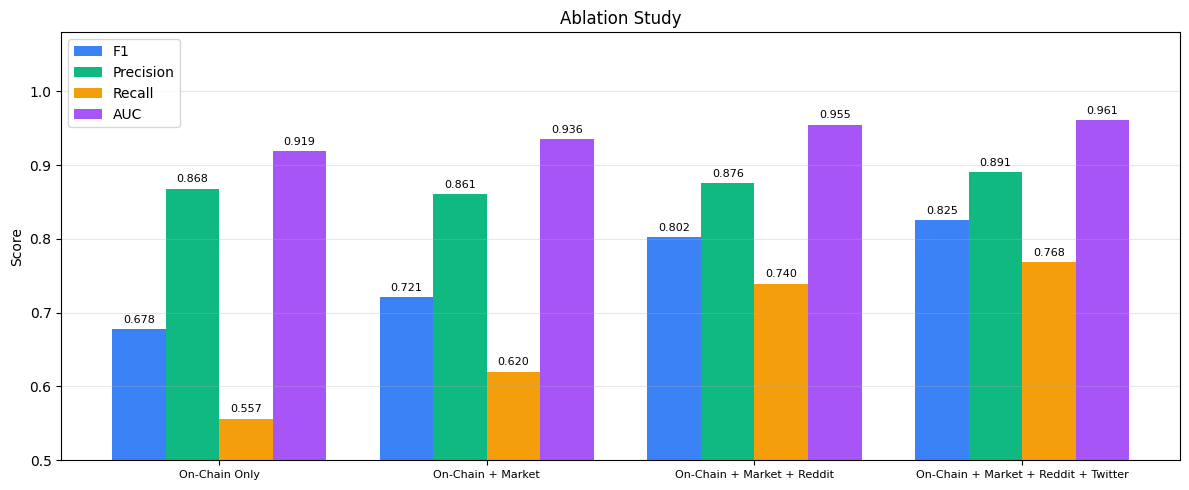

In [8]:
metrics = ['F1', 'Precision', 'Recall', 'AUC']
colors  = ['#3b82f6', '#10b981', '#f59e0b', '#a855f7']

x = range(len(abl_df))
plt.figure(figsize=(12, 5))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = plt.bar([xi + (i-1.5)*0.2 for xi in x], abl_df[metric], 0.2, color=color, label=metric)
    plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

plt.xticks(x, abl_df['Model'], fontsize=8)
plt.ylabel("Score")
plt.title("Ablation Study")
plt.ylim(0.5, 1.08)
plt.grid(alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

### Evaluation Plots

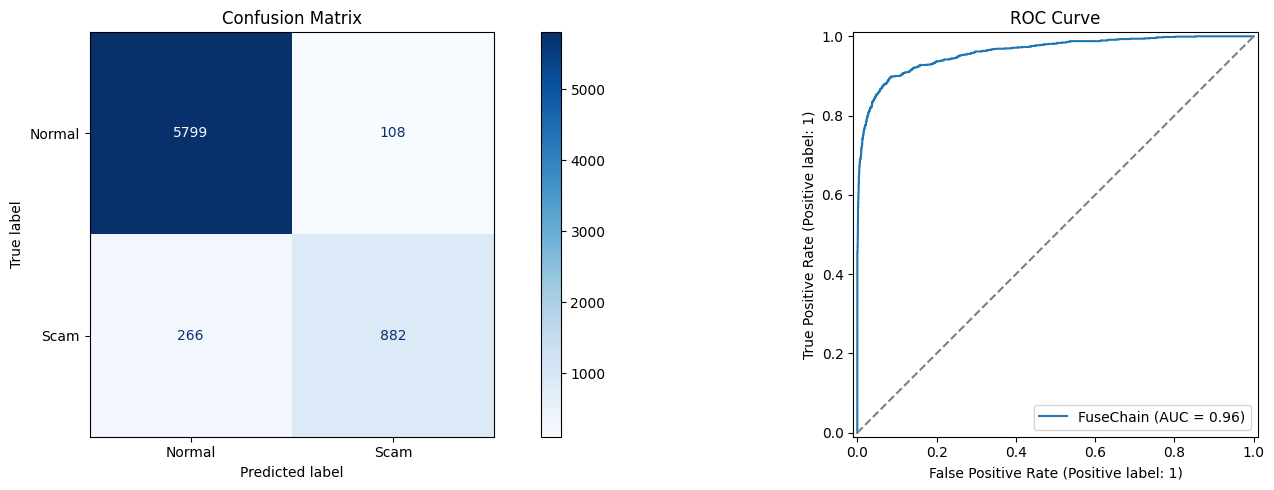

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(18,5))

ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, display_labels=['Normal','Scam'], cmap='Blues', ax=axes[0])

axes[0].set_title("Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, y_test_prob, ax=axes[1], name="FuseChain")

axes[1].plot([0,1],[0,1], linestyle='--', color='gray')
axes[1].set_title("ROC Curve")
plt.tight_layout()
plt.show()

### SHAP Analysis

In [10]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

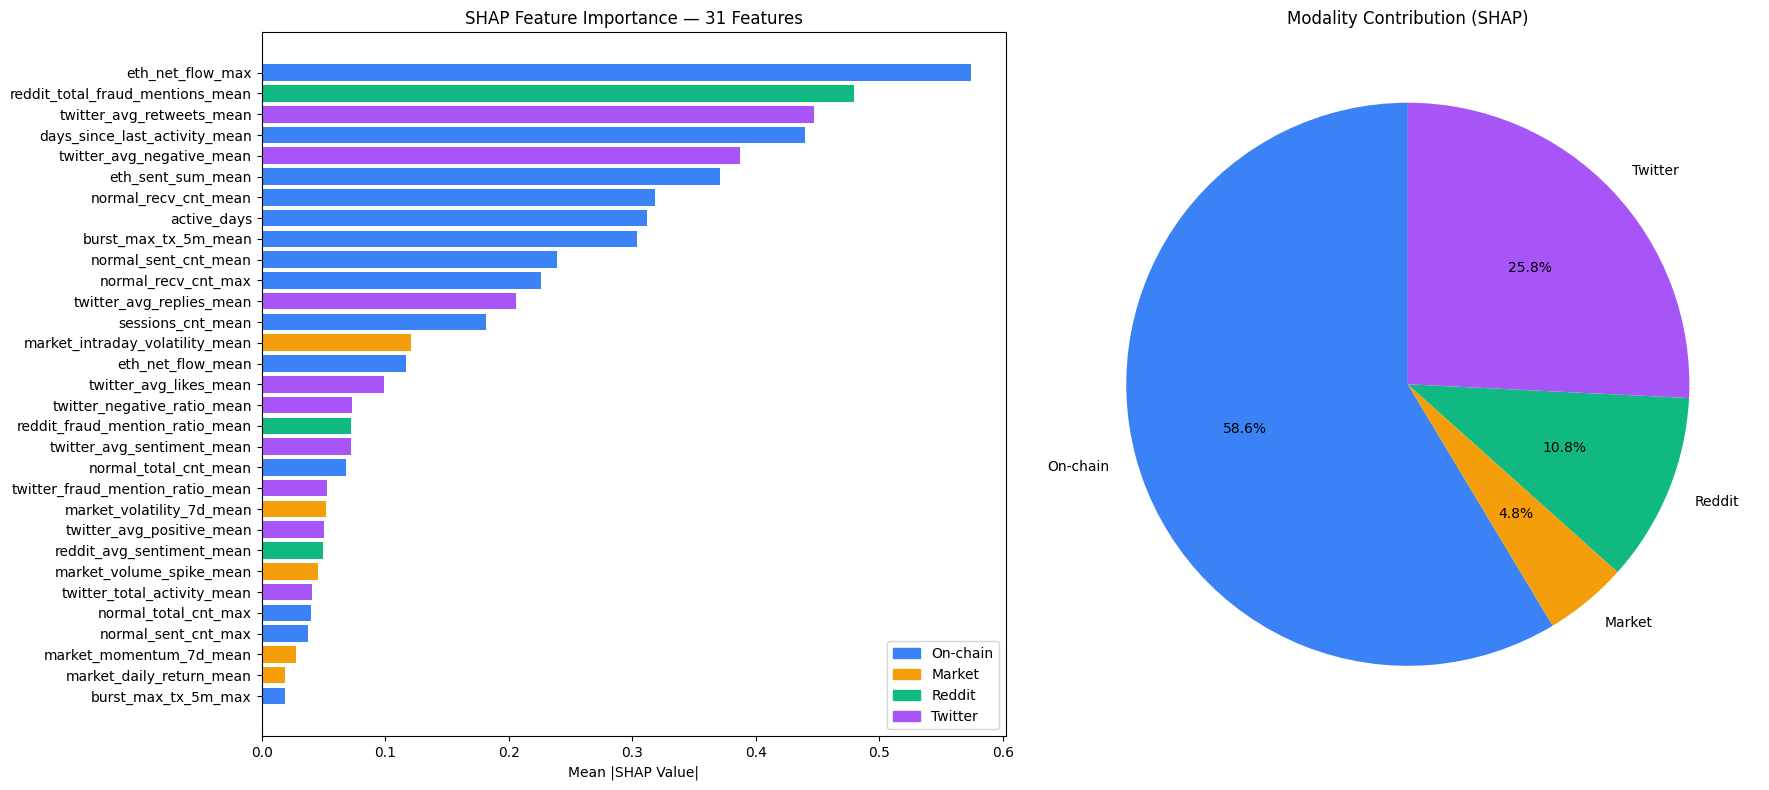

In [11]:
mean_shap = np.abs(shap_values).mean(axis=0)
importance = pd.Series(mean_shap, index=ALL_FEATURES).sort_values(ascending=False)

def get_color(f):
    if f.startswith('market_'): return '#f59e0b'
    if f.startswith('reddit_'): return '#10b981'
    if f.startswith('twitter_'): return '#a855f7'
    return '#3b82f6'

colors = [get_color(f) for f in importance.index]

# calculate modality totals
mod_totals = {"On-chain": 0, "Market": 0, "Reddit": 0, "Twitter": 0}
for f, v in zip(ALL_FEATURES, mean_shap):
    if f.startswith('market_'):    mod_totals["Market"] += v
    elif f.startswith('reddit_'):  mod_totals["Reddit"] += v
    elif f.startswith('twitter_'): mod_totals["Twitter"] += v
    else:                          mod_totals["On-chain"] += v

# side by side plots
fig, axes = plt.subplots(1, 2, figsize=(18, max(8, len(importance) * 0.15)))

# Left: SHAP feature importance
axes[0].barh(importance.index, importance.values, color=colors)
axes[0].set_xlabel("Mean |SHAP Value|")
axes[0].set_title(f"SHAP Feature Importance — {len(ALL_FEATURES)} Features")
axes[0].invert_yaxis()
axes[0].legend(handles=[
    Patch(color='#3b82f6', label='On-chain'),
    Patch(color='#f59e0b', label='Market'),
    Patch(color='#10b981', label='Reddit'),
    Patch(color='#a855f7', label='Twitter'),
], loc='lower right')

# Right: Modality contribution pie chart
axes[1].pie(mod_totals.values(), labels=mod_totals.keys(),
            colors=['#3b82f6', '#f59e0b', '#10b981', '#a855f7'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title("Modality Contribution (SHAP)")

plt.tight_layout()
plt.show()

### Save Model

In [12]:
cols = ['address', 'is_scam'] + ALL_FEATURES

train_df = df.loc[X_train.index, cols]
train_df.to_parquet("../data/processed/final/train_set.parquet", index=False)

test_df = df.loc[X_test.index, cols]
test_df.to_parquet("../data/processed/final/test_set.parquet", index=False)

In [13]:
os.makedirs("../../models", exist_ok=True)
model_artifact = {
    'model': final_model,
    'feature_columns': ALL_FEATURES,
    'target_column': TARGET
}
joblib.dump(model_artifact, "../../models/xgboost_address_model.joblib")
print("Model saved")

Model saved


### Demo Addresses

In [14]:
demo_scams = test_df[test_df['is_scam'] == 1].sample(10, random_state=42)
demo_normals = test_df[test_df['is_scam'] == 0].sample(10, random_state=42)

demo = pd.concat([demo_scams, demo_normals])
demo[['address', 'is_scam']].to_csv("../../models/demo_labeled_addresses.csv", index=False)
demo[['address']].to_csv("../../models/demo_unlabeled_addresses.csv", index=False)

print("test files saved")

test files saved
